In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.2f}'.format

In [5]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv')

In [6]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,Feb,3,3,1,4,Returning_Visitor,True,False


# E-commerce Customer Intent Dataset: Feature Description

This dataset consists of **12,330 sessions**, where **Revenue** serves as the target class (84.5% negative samples, 15.5% positive samples). Below is the detailed breakdown of the attributes:

## 1. Page Statistics

These features represent the types of pages visited and the time spent on them. They are updated in real-time based on URL information.

* **Administrative**: Number of administrative pages visited in the session.
* **Administrative_Duration**: Total time spent on administrative pages.
* **Informational**: Number of informational pages visited.
* **Informational_Duration**: Total time spent on informational pages.
* **ProductRelated**: Number of product-related pages visited.
* **ProductRelated_Duration**: Total time spent on product-related pages.

## 2. Google Analytics Metrics

These features are derived from standard e-commerce performance metrics.

* **BounceRates**: The percentage of visitors who enter the site from that page and leave ("bounce") without any further requests.
* **ExitRates**: The percentage of views to a page that were the last in the session.
* **PageValues**: The average value of a web page visited before completing a transaction.

## 3. Contextual and Temporal Features

* **SpecialDay**: Indicates the proximity to a special day (e.g., Valentine's Day).
* *Example:* For Valentine's Day, it reaches a maximum value of **1.0** on Feb 8th and returns to **0** after Feb 12th, accounting for shipping/delivery times.


* **Month**: The month of the year in which the session occurred.
* **Weekend**: A Boolean value (True/False) indicating if the visit happened on a weekend.

## 4. Technical and User Information

* **OperatingSystems**: The OS used by the visitor (encoded as integers).
* **Browser**: The browser used by the visitor (encoded as integers).
* **Region**: The geographic region of the visitor.
* **TrafficType**: The source of traffic that brought the user to the site.
* **VisitorType**: Whether the user is a `New_Visitor`, `Returning_Visitor`, or `Other`.

## 5. Target Variable

* **Revenue**: A Boolean value (True/False) indicating whether the session finalized in a purchase.

---

### Dataset Summary Table

| Attribute Category | Count | Type |
| --- | --- | --- |
| **Numerical** | 10 | int64, float64 |
| **Categorical/Other** | 8 | object, bool |
| **Total Samples** | 12,330 | - |

## EDA

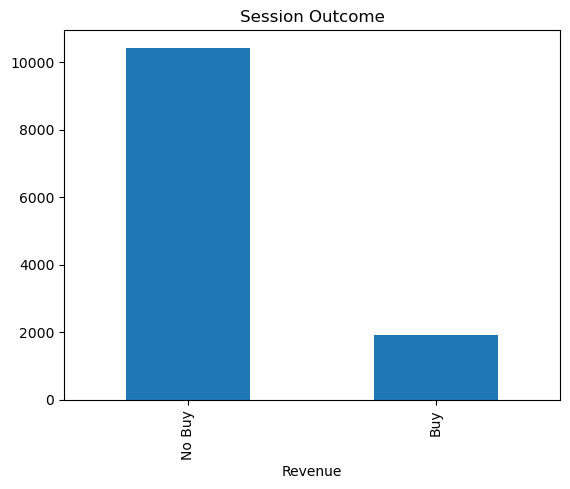

In [7]:
label_map = {True: 'Buy', False: 'No Buy'}

df['Revenue'].map(label_map).value_counts().plot(
    kind = 'bar',
    title="Session Outcome"
)
plt.show()

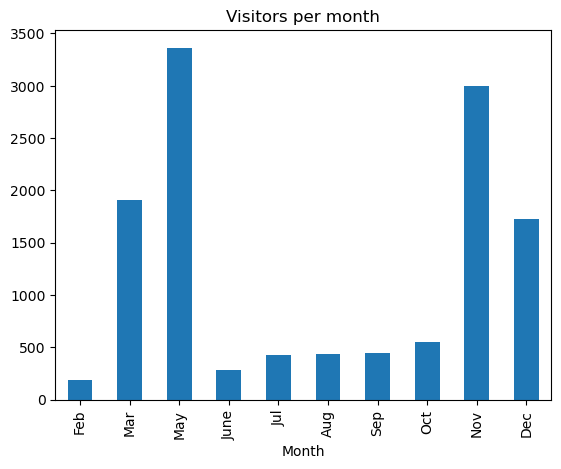

In [8]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
df['Month'].value_counts().sort_index().plot(kind="bar")
plt.title('Visitors per month')
plt.show()

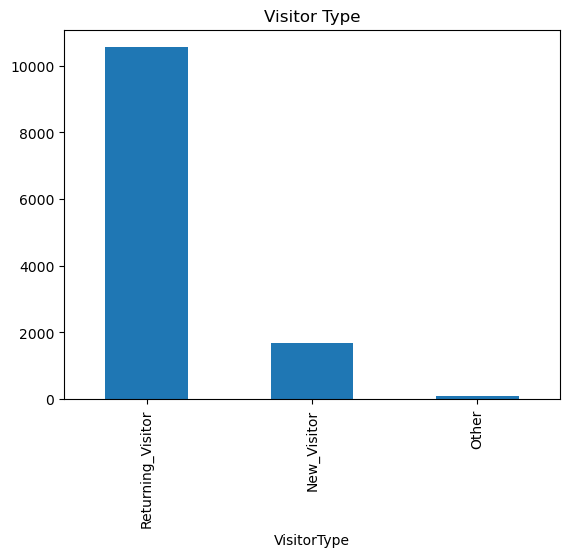

In [9]:
df['VisitorType'].value_counts().plot(kind="bar")
plt.title('Visitor Type')
plt.show()

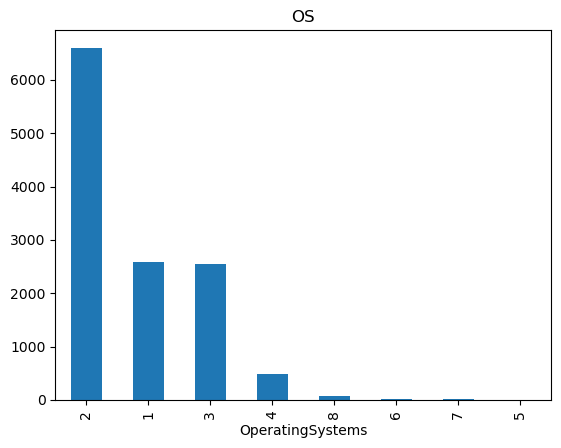

In [10]:
df['OperatingSystems'].value_counts().plot(kind="bar")
plt.title('OS')
plt.show()

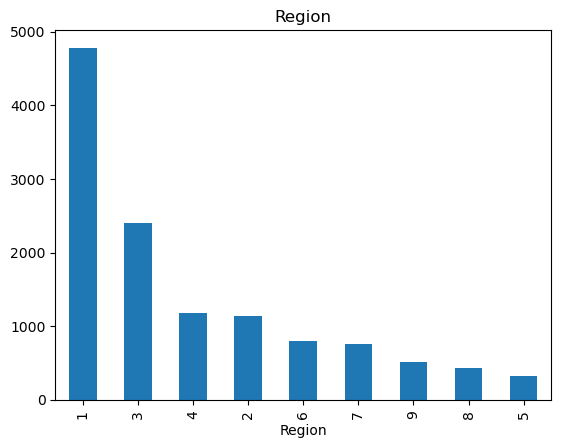

In [11]:
df['Region'].value_counts().plot(kind="bar")
plt.title('Region')
plt.show()

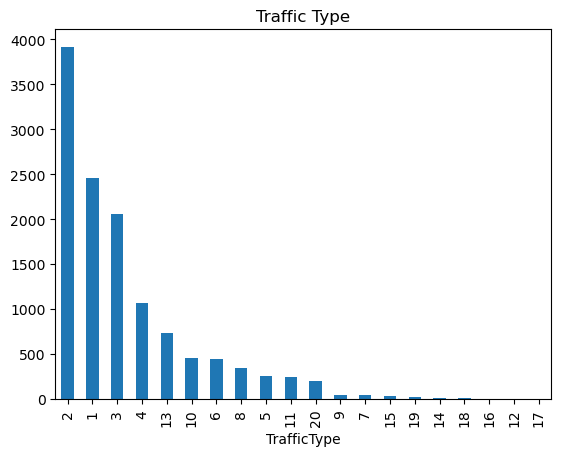

In [12]:
df['TrafficType'].value_counts().plot(kind="bar")
plt.title('Traffic Type')
plt.show()

In [13]:
buyers_df = df[df['Revenue']==True].copy()

In [14]:
buyers_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
65,3,87.83,0,0.00,27,798.33,0.00,0.01,22.92,0.80,Feb,2,2,3,1,Returning_Visitor,False,True
76,10,1005.67,0,0.00,36,2111.34,0.00,0.01,11.44,0.00,Feb,2,6,1,2,Returning_Visitor,False,True
101,4,61.00,0,0.00,19,607.00,0.00,0.03,17.54,1.00,Feb,1,1,7,4,Returning_Visitor,True,True
188,9,111.50,1,48.50,49,1868.82,0.00,0.02,1.71,0.00,Mar,2,2,7,2,Returning_Visitor,False,True
196,2,56.00,1,144.00,67,2563.78,0.00,0.01,19.34,0.00,Mar,2,2,4,2,New_Visitor,False,True


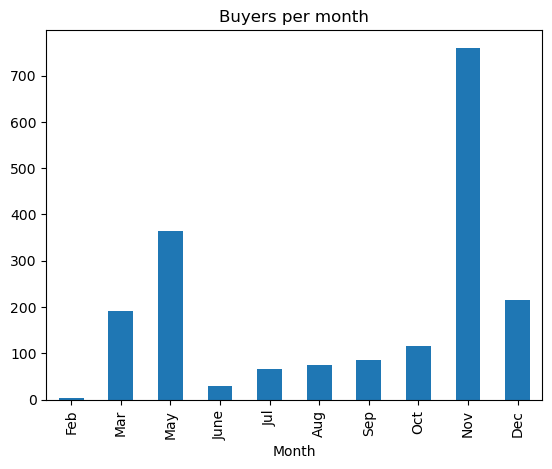

In [15]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
buyers_df['Month'] = pd.Categorical(buyers_df['Month'], categories=month_order, ordered=True)
buyers_df['Month'].value_counts().sort_index().plot(kind="bar")
plt.title('Buyers per month')
plt.show()

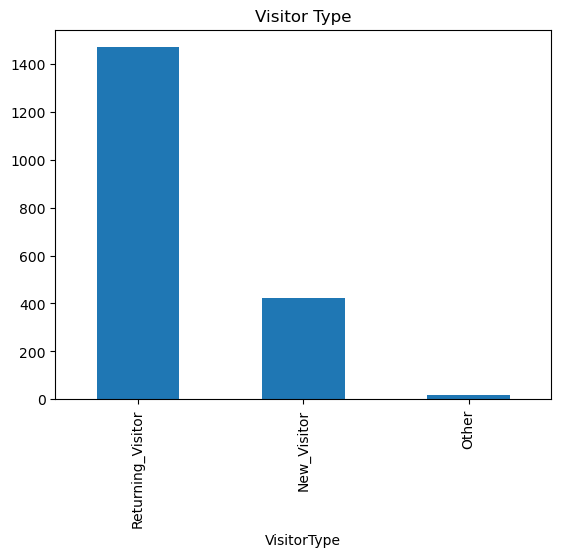

In [16]:
buyers_df['VisitorType'].value_counts().plot(kind="bar")
plt.title('Visitor Type')
plt.show()

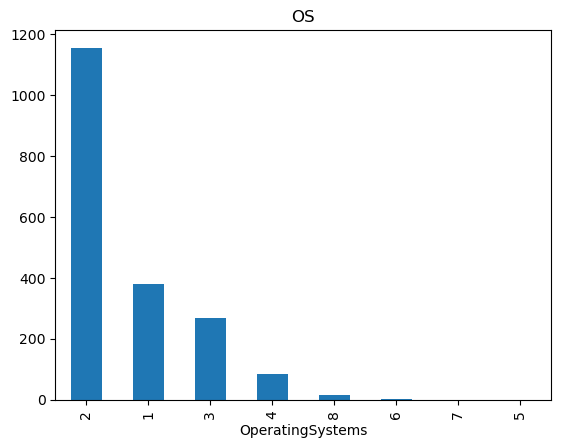

In [17]:
buyers_df['OperatingSystems'].value_counts().plot(kind="bar")
plt.title('OS')
plt.show()

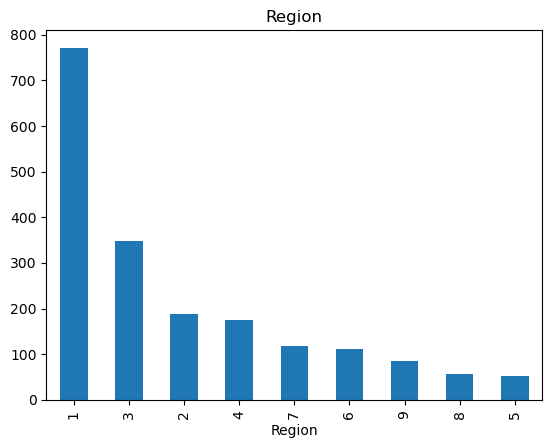

In [18]:
buyers_df['Region'].value_counts().plot(kind="bar")
plt.title('Region')
plt.show()

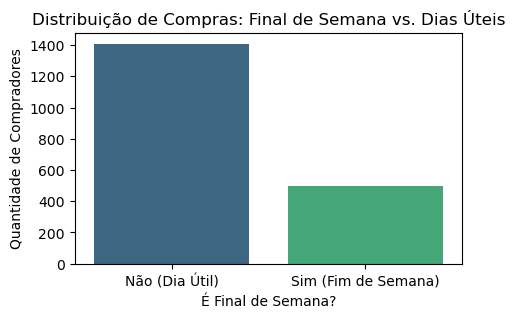

In [19]:
plt.figure(figsize=(5, 3))
# Usando o seaborn para um visual mais profissional
sns.countplot(data=buyers_df, x='Weekend', hue='Weekend', palette='viridis', legend=False)

plt.title('Distribuição de Compras: Final de Semana vs. Dias Úteis')
plt.xlabel('É Final de Semana?')
plt.ylabel('Quantidade de Compradores')
plt.xticks([0, 1], ['Não (Dia Útil)', 'Sim (Fim de Semana)']) # Melhora a leitura
plt.show()

In [20]:
buyers_df.shape

(1908, 18)

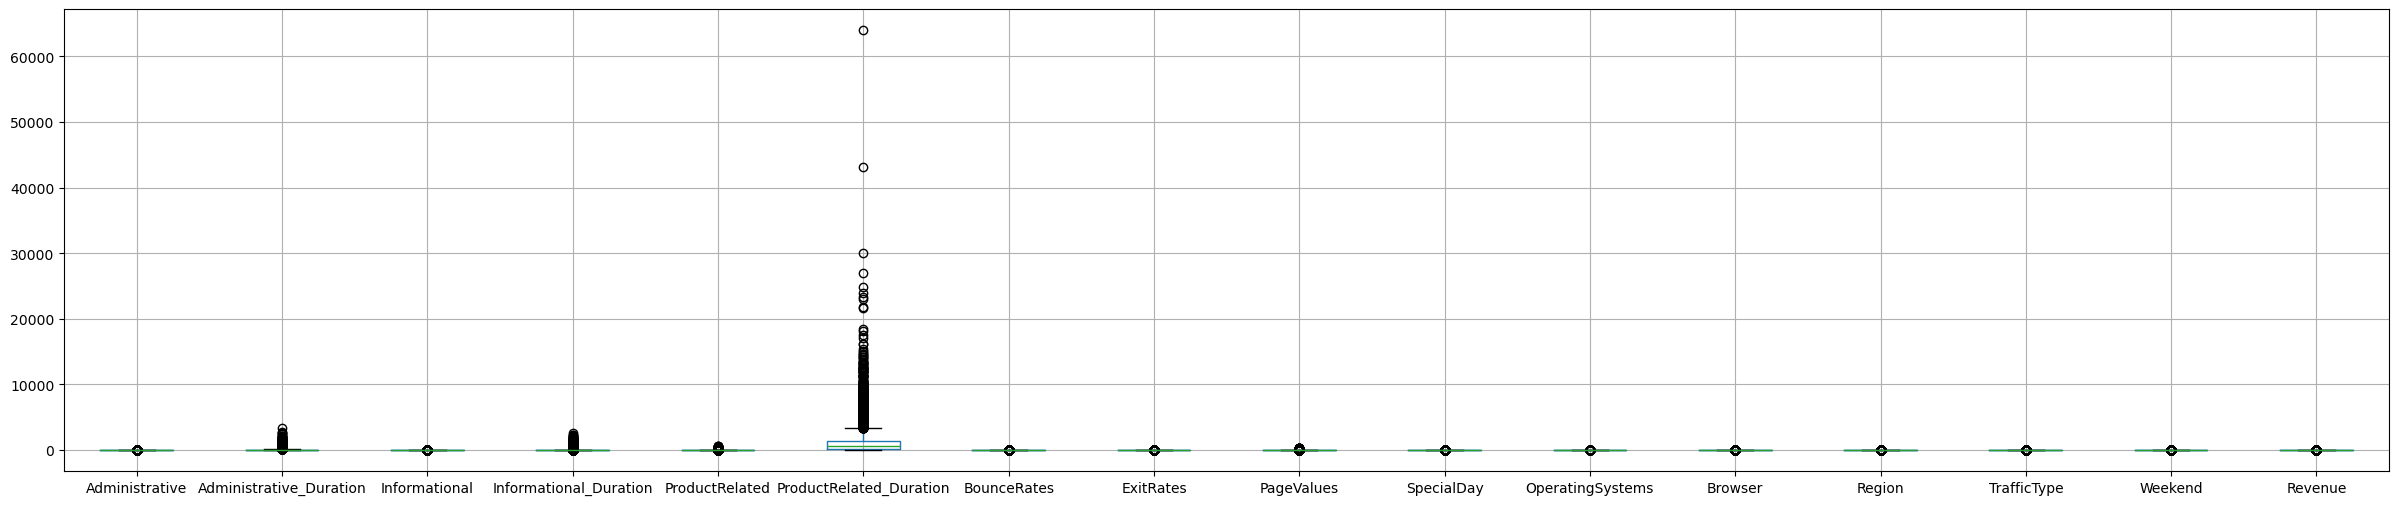

In [21]:
plt.figure(figsize=(30, 6))
df.boxplot()
plt.show()

In [22]:
df[df['ProductRelated_Duration'] > 3600].shape[0]

867

In [23]:
df[df['ProductRelated_Duration'] > 3600].shape[0]/df.shape[0]*100

7.031630170316301

## Data Processing

In [24]:
processed_df = pd.get_dummies(df, columns=['Month', 'VisitorType'])

In [25]:
processed_df.head(100)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Jul,Month_Aug,Month_Sep,Month_Oct,Month_Nov,Month_Dec,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0.00,0,0.00,2,33.00,0.00,0.10,0.00,0.20,...,False,False,False,False,False,False,False,False,False,True
96,0,0.00,0,0.00,6,1566.50,0.05,0.07,0.00,0.20,...,False,False,False,False,False,False,False,False,False,True
97,0,0.00,0,0.00,4,105.00,0.00,0.03,0.00,0.60,...,False,False,False,False,False,False,False,False,False,True
98,0,0.00,1,0.00,7,50.00,0.04,0.08,0.00,0.60,...,False,False,False,False,False,False,False,False,False,True


In [26]:
processed_df.shape

(12330, 29)

In [27]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [28]:
processed_df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


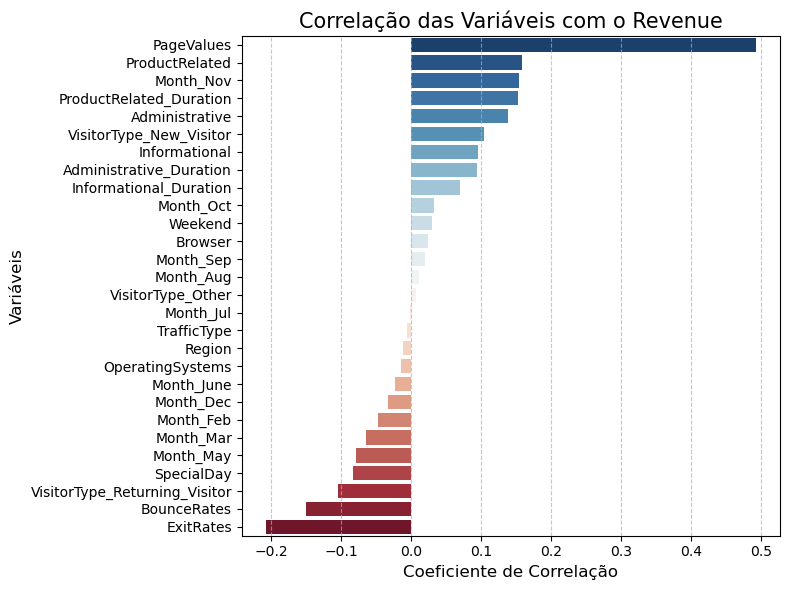

In [29]:
# 1. Calculando a correlação de todas as colunas com a coluna 'Revenue'
# O pandas transformará automaticamente True/False em 1/0 para o cálculo
correlations = processed_df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)

correlations = correlations.drop('Revenue')

# 3. Criando o gráfico de barras
plt.figure(figsize=(8, 6)) # Ajustamos a altura pois agora há muitas colunas (dummies)
sns.barplot(x=correlations.values, y=correlations.index, hue=correlations.index,palette='RdBu_r')

plt.title('Correlação das Variáveis com o Revenue', fontsize=15)
plt.xlabel('Coeficiente de Correlação', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
# Calculando a correlação numérica
correlacoes = processed_df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)

# Exibindo os valores
print("Correlação das variáveis com o Sucesso de Venda (Revenue):")
print(correlacoes)

Correlação das variáveis com o Sucesso de Venda (Revenue):
Revenue                          1.00
PageValues                       0.49
ProductRelated                   0.16
Month_Nov                        0.15
ProductRelated_Duration          0.15
Administrative                   0.14
VisitorType_New_Visitor          0.10
Informational                    0.10
Administrative_Duration          0.09
Informational_Duration           0.07
Month_Oct                        0.03
Weekend                          0.03
Browser                          0.02
Month_Sep                        0.02
Month_Aug                        0.01
VisitorType_Other                0.01
Month_Jul                       -0.00
TrafficType                     -0.01
Region                          -0.01
OperatingSystems                -0.01
Month_June                      -0.02
Month_Dec                       -0.03
Month_Feb                       -0.05
Month_Mar                       -0.06
Month_May                    

## training and testing

In [36]:
Preditoras = processed_df.drop('Revenue', axis=1)
Target = processed_df['Revenue']

In [37]:
Preditoras

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Jul,Month_Aug,Month_Sep,Month_Oct,Month_Nov,Month_Dec,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.00,0,0.00,53,1783.79,0.01,0.03,12.24,0.00,...,False,False,False,False,False,False,True,False,False,True
12326,0,0.00,0,0.00,5,465.75,0.00,0.02,0.00,0.00,...,False,False,False,False,False,True,False,False,False,True
12327,0,0.00,0,0.00,6,184.25,0.08,0.09,0.00,0.00,...,False,False,False,False,False,True,False,False,False,True
12328,4,75.00,0,0.00,15,346.00,0.00,0.02,0.00,0.00,...,False,False,False,False,False,True,False,False,False,True


In [38]:
Target

0        False
1        False
2        False
3        False
4        False
         ...  
12325    False
12326    False
12327    False
12328    False
12329    False
Name: Revenue, Length: 12330, dtype: bool

<Axes: xlabel='Revenue'>

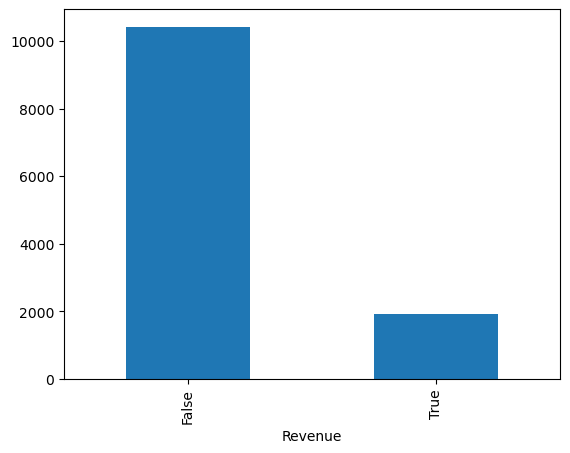

In [39]:
Target.value_counts().plot(kind = 'bar')

In [40]:
Target.shape

(12330,)

In [41]:
Target.value_counts().plot(kind = 'bar')

NameError: name 'Target_Res' is not defined

In [ ]:
Target_Res.shape

In [43]:

X_train, X_test, y_train, y_test = train_test_split(
    Preditoras, 
    Target, 
    test_size=0.3, 
    random_state=42,
    stratify=Target # Garante a mesma proporção de classes
)

# 2. Agora aplicamos o SMOTE APENAS nos dados de treino que separamos acima
seed = 100
balanceador = SMOTE(random_state=seed)

X_train_res, y_train_res = balanceador.fit_resample(X_train, y_train)

In [44]:
X_train.shape

(8631, 28)

In [45]:
y_train.shape

(8631,)

In [46]:
from sklearn.pipeline import make_pipeline

# Em vez de apenas LogisticRegression(), use um Pipeline.
# Ele vai aplicar o scaler (ajustar as escalas) e depois o modelo.
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Treine o pipeline completo
model.fit(X_train_res, y_train_res)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [47]:
y_pred = model.predict(X_test)

In [48]:
model.score(X_test,y_test)

0.881859962151933

In [49]:
model.predict_proba(X_test)

array([[0.99247375, 0.00752625],
       [0.9632028 , 0.0367972 ],
       [0.81325587, 0.18674413],
       ...,
       [0.92045583, 0.07954417],
       [0.83751264, 0.16248736],
       [0.90280631, 0.09719369]], shape=(3699, 2))

1. Precision (Precisão)
Responde: "De todos os clientes que o modelo disse que iam comprar, quantos realmente compraram?"

Se for alta: O modelo é cauteloso. Quando ele diz "vai comprar", ele costuma estar certo.

Se for baixa: O modelo dá muitos "alarmes falsos" (Falsos Positivos).

2. Recall (Revocação)
Responde: "De todos os clientes que realmente compraram, quantos o modelo conseguiu identificar?"

Se for alta: O modelo consegue "pescar" quase todos os compradores reais.

Se for baixa: O modelo está a deixar passar muitos compradores (Falsos Negativos), perdendo oportunidades de conversão.

3. F1-Score
É a média harmônica entre a Precisão e o Recall. É a melhor métrica para observar quando você busca um equilíbrio entre não dar alarmes falsos e não ignorar compradores reais.

4. Support (Suporte)
Indica a quantidade de exemplos reais de cada classe no seu conjunto de teste (y_test).

No dataset online_shoppers_intention.csv, o suporte para a classe False (não comprou) é muito maior que para a classe True (comprou), refletindo o desequilíbrio real do mercado (aprox. 84,5% vs 15,5%).

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.92      0.95      0.93      3127
        True       0.65      0.52      0.58       572

    accuracy                           0.88      3699
   macro avg       0.78      0.73      0.75      3699
weighted avg       0.87      0.88      0.88      3699



In [51]:
y_proba = model.predict_proba(X_test)[:, 1]

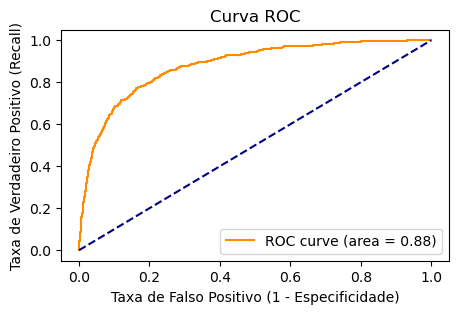

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcula a curva
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plota a Curva ROC
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

Melhor Threshold: 0.3434
Maior F1-Score atingido: 0.6097


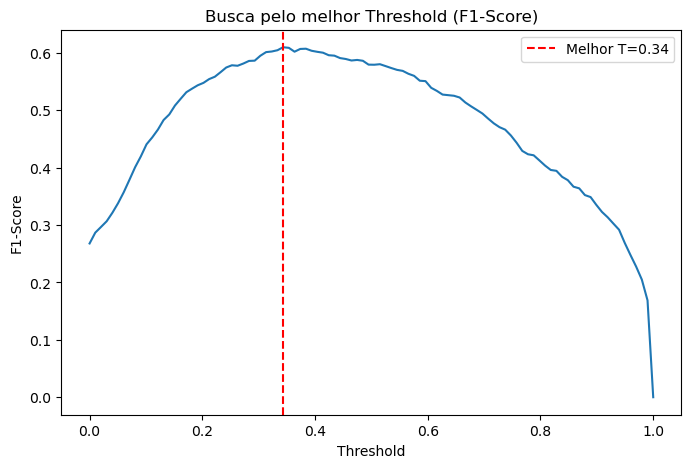

In [53]:
from sklearn.metrics import f1_score
import numpy as np

# Criamos uma lista de possíveis thresholds de 0.01 até 0.99
lista_thresholds = np.linspace(0, 1, 100)
f1_scores = []

for t in lista_thresholds:
    # Se a probabilidade for maior que 't', classifica como True
    y_pred_temp = (y_proba >= t)
    f1_scores.append(f1_score(y_test, y_pred_temp))

# Encontra o índice do maior F1
idx_melhor_t = np.argmax(f1_scores)
melhor_threshold = lista_thresholds[idx_melhor_t]
maior_f1 = f1_scores[idx_melhor_t]

print(f"Melhor Threshold: {melhor_threshold:.4f}")
print(f"Maior F1-Score atingido: {maior_f1:.4f}")

# Gráfico da busca pelo melhor threshold
plt.figure(figsize=(8, 5))
plt.plot(lista_thresholds, f1_scores)
plt.axvline(melhor_threshold, color='red', linestyle='--', label=f'Melhor T={melhor_threshold:.2f}')
plt.title('Busca pelo melhor Threshold (F1-Score)')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.show()

In [54]:
from sklearn.metrics import classification_report

# Aplicando o melhor threshold encontrado
y_pred_otimizado = (y_proba >= melhor_threshold)

print("Relatório de Classificação com Threshold Otimizado:")
print(classification_report(y_test, y_pred_otimizado))

Relatório de Classificação com Threshold Otimizado:
              precision    recall  f1-score   support

       False       0.94      0.90      0.92      3127
        True       0.55      0.68      0.61       572

    accuracy                           0.87      3699
   macro avg       0.75      0.79      0.76      3699
weighted avg       0.88      0.87      0.87      3699



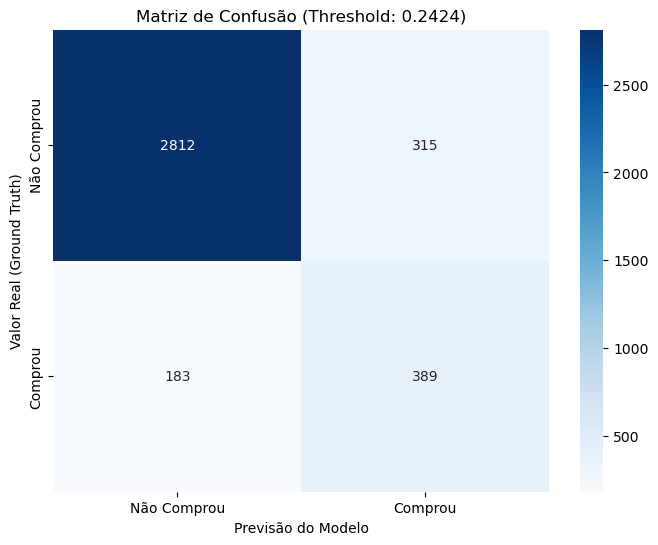

In [55]:
from sklearn.metrics import confusion_matrix

# 1. Gerar as previsões usando o threshold otimizado
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_otimizado = (y_proba >= melhor_threshold)

# 2. Criar a matriz
cm = confusion_matrix(y_test, y_pred_otimizado)

# 3. Plotar usando o Seaborn para ficar visual
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Comprou', 'Comprou'], 
            yticklabels=['Não Comprou', 'Comprou'])

plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusão (Threshold: 0.2424)')
plt.show()

In [56]:
# 1. Acessar o coeficiente dentro do pipeline
# O [1] acessa o segundo passo do pipeline (a LogisticRegression)
coeficientes = model.named_steps['logisticregression'].coef_[0]

# 2. Pegar os nomes das colunas (features) que você usou no X_train
features = X_train.columns

# 3. Criar um DataFrame para facilitar a visualização
importancia_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': coeficientes
}).sort_values(by='Coeficiente', ascending=False)

# 4. Exibir os valores numéricos
print(importancia_df)

                          Feature  Coeficiente
23                      Month_Nov         3.79
17                      Month_May         3.00
8                      PageValues         2.56
25        VisitorType_New_Visitor         2.45
24                      Month_Dec         2.42
16                      Month_Mar         2.38
27  VisitorType_Returning_Visitor         1.88
22                      Month_Oct         1.75
21                      Month_Sep         1.60
20                      Month_Aug         1.55
19                      Month_Jul         1.32
18                     Month_June         1.02
26              VisitorType_Other         0.61
15                      Month_Feb         0.47
4                  ProductRelated         0.27
14                        Weekend         0.26
5         ProductRelated_Duration         0.12
3          Informational_Duration        -0.00
11                        Browser        -0.00
0                  Administrative        -0.01
1         Adm

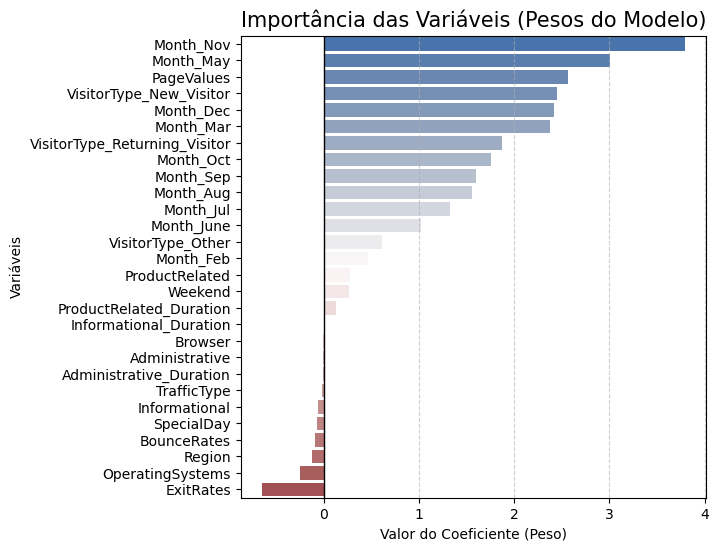

In [57]:
plt.figure(figsize=(6, 6))
sns.barplot(
    data=importancia_df, 
    x='Coeficiente', 
    y='Feature', 
    hue='Feature', 
    palette='vlag', 
    legend=False
)

plt.title('Importância das Variáveis (Pesos do Modelo)', fontsize=15)
plt.xlabel('Valor do Coeficiente (Peso)')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.axvline(0, color='black', lw=1) # Linha no zero para separar positivo de negativo
plt.show()

In [58]:
## Score Treino vs Teste

print(f"Score Treino: {model.score(X_train, y_train):.4f}")
print(f"Score Teste:  {model.score(X_test, y_test):.4f}")


Score Treino: 0.8897
Score Teste:  0.8819
